In [442]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, accuracy_score
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import shap
import joblib

In [443]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('actual')
    plt.xlabel('predicted')
    plt.show()

In [ ]:
# define column names
column_names = [
    'mean_profile', 'std_profile', 'kurtosis_profile', 'skewness_profile',
    'mean_dmsnr', 'std_dmsnr', 'kurtosis_dmsnr', 'skewness_dmsnr', 'class'
]

# load with manual names
data = pd.read_csv('/data/HTRU_2.csv', header=None, names=column_names)

## feature engineering

In [445]:
# core physics ratios
data['snr_robustness'] = data['mean_profile'] / (data['std_dmsnr'] + 1e-9)
data['peak_to_noise'] = data['mean_profile'] / (data['skewness_dmsnr'] + 1e-9)
data['sharpness_index'] = data['kurtosis_profile'] / data['std_profile']
data['ism_factor'] = data['mean_dmsnr'] * data['skewness_dmsnr']

# advanced signatures
data['pulsar_signature_score'] = data['kurtosis_profile'] * data['sharpness_index']
data['energy_concentration'] = data['mean_profile'] * data['sharpness_index']
data['log_dm_skew'] = np.log1p(data['skewness_dmsnr'].abs())

# log transforms for skewed distributions
skewed_cols = ['kurtosis_profile', 'sharpness_index', 'pulsar_signature_score']
for col in skewed_cols:
    data[f'log_{col}'] = np.log1p(data[col].abs())

print(f"final data shape: {data.shape}")

final data shape: (17898, 19)


## split

In [446]:
X = data.drop('class', axis=1)
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## scaling

In [447]:
# scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## model validation (stratified k-fold)

In [448]:
cv_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42,
    eval_metric='logloss'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X_train_scaled, y_train, cv=skf, scoring='f1')

print("5-fold cross-validation results:")
print(f"f1 scores: {cv_scores}")
print(f"mean f1: {cv_scores.mean():.4f}")
print(f"standard deviation: {cv_scores.std():.4f}")

5-fold cross-validation results:
f1 scores: [0.85       0.87985213 0.8815534  0.88180113 0.89219331]
mean f1: 0.8771
standard deviation: 0.0142


## XGBoost

balanced threshold: 0.6495
classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.90      0.90      0.90       328

    accuracy                           0.98      3580
   macro avg       0.94      0.94      0.94      3580
weighted avg       0.98      0.98      0.98      3580



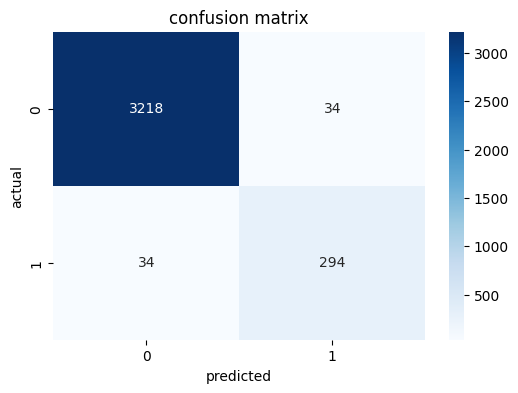

In [449]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# squeeze logic
thresholds_to_test = np.linspace(0.5, 0.9, 100)
best_diff = float('inf')
best_threshold = 0.5

for t in thresholds_to_test:
    preds = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    diff = abs(fp - fn)
    if diff < best_diff:
        best_diff = diff
        best_threshold = t

y_pred_optimized = (y_probs >= best_threshold).astype(int)

print(f"balanced threshold: {best_threshold:.4f}")
print("classification report:")
print(classification_report(y_test, y_pred_optimized))
plot_cm(y_test, y_pred_optimized, "confusion matrix")

## model distribution

In [450]:
confidence_scores = model.predict_proba(X_test_scaled)[:, 1]

print("xgboost raw probability distribution:")
print(f"min: {confidence_scores.min():.4f}")
print(f"max: {confidence_scores.max():.4f}")
print(f"mean: {confidence_scores.mean():.4f}")
print(f"median: {np.median(confidence_scores):.4f}")
print(f"\ndistribution by threshold:")
for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
    count = (confidence_scores >= thresh).sum()
    pulsars = y_test.values[confidence_scores >= thresh].sum()
    prec = pulsars / count * 100 if count > 0 else 0
    print(f"  ≥{thresh}: {count} candidates, {pulsars} true pulsars, {prec:.1f}% precision")

xgboost raw probability distribution:
min: 0.0000
max: 0.9997
mean: 0.1096
median: 0.0041

distribution by threshold:
  ≥0.5: 349 candidates, 295 true pulsars, 84.5% precision
  ≥0.6: 339 candidates, 295 true pulsars, 87.0% precision
  ≥0.7: 325 candidates, 293 true pulsars, 90.2% precision
  ≥0.8: 318 candidates, 289 true pulsars, 90.9% precision
  ≥0.9: 300 candidates, 281 true pulsars, 93.7% precision


## PR curve

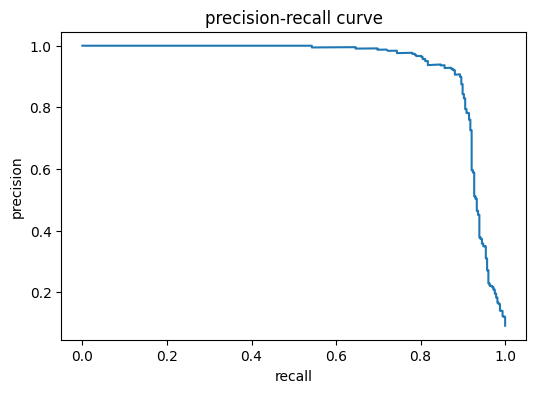

In [451]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("precision-recall curve")
plt.show()

## top features

In [452]:
importances = model.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
print("\ntop features:")
print(feat_imp.head(10))


top features:
kurtosis_profile              0.446337
log_kurtosis_profile          0.175348
pulsar_signature_score        0.077636
sharpness_index               0.031134
energy_concentration          0.027696
log_pulsar_signature_score    0.027578
std_dmsnr                     0.027164
snr_robustness                0.025870
kurtosis_dmsnr                0.021089
ism_factor                    0.020209
dtype: float32


## thresholding

In [453]:
confidence_scores = model.predict_proba(X_test_scaled)[:, 1]
DISCOVERY_THRESHOLD = 0.9

discoveries_idx = np.where(confidence_scores >= DISCOVERY_THRESHOLD)[0]
true_discoveries = y_test.values[discoveries_idx]

print(f"candidates flagged: {len(discoveries_idx)}")
print(f"true pulsars: {true_discoveries.sum()}")
print(f"precision: {true_discoveries.sum()/len(discoveries_idx)*100:.1f}%")

stage_final = {
    'confidence_scores': confidence_scores,
    'discoveries_idx': discoveries_idx,
    'threshold': DISCOVERY_THRESHOLD,
    'y_true': y_test.values,
    'X_test': X_test_scaled
}

candidates flagged: 300
true pulsars: 281
precision: 93.7%


## SHAP

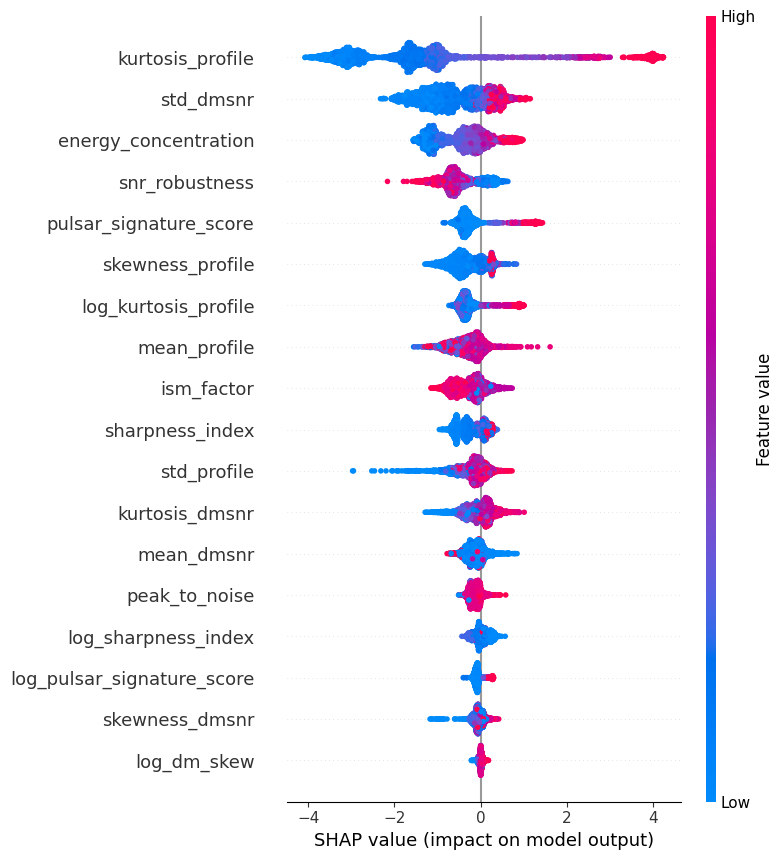

In [454]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)
plt.figure(figsize=(6, 4))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
plt.show()

## save the model and the scaler

In [455]:
joblib.dump(model, 'pulsar_xgb_model.pkl')
joblib.dump(scaler, 'robust_scaler.pkl')
print("model and scaler exported successfully.")

model and scaler exported successfully.
